# **Heart Attack Risk Classification**

## **Problem Statement**
The goal of this project is to develop a **classification model** that can predict the likelihood of a **heart attack** based on various **patient health indicators**. The dataset contains information on patients' demographic details, medical history, and diagnostic measures. The primary objective is to accurately classify patients into two categories: those with a higher likelihood of experiencing a heart attack (**target = 1**) and those with a lower likelihood (**target = 0**).

## **Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## **Load dataset**

In [ ]:
data = pd.read_csv('heart.csv')


## **Understanding Variables**
**Age** – Age of the patient in years.

**Sex** – Gender of the patient (M = Male, F = Female).

**ChestPainType** – Type of chest pain experienced by the patient.

**RestingBP** – Blood pressure level when the patient is at rest.

**Cholesterol** – Cholesterol level in the patient’s blood.

**FastingBS** – Whether fasting blood sugar is high (1 = Yes, 0 = No).

**RestingECG** – Result of the resting electrocardiogram test.

**MaxHR** – Maximum heart rate achieved during exercise.

**ExerciseAngina** – Whether chest pain occurs during exercise (Y = Yes, N = No).

**Oldpeak** – ST depression value measured during exercise (heart stress indicator).

**ST_Slope** – Slope pattern of the ST segment during peak exercise.

**HeartDisease** – Whether the patient has heart disease (1 = Yes, 0 = No).

## **Basic Checks**

In [ ]:
# checking number of rows and columns
data.shape

(918, 12)

In [ ]:
# print first 5 rows
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
# print last 5 rows
data.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [ ]:
# check info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
# check data type
data.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


In [ ]:
# print all columns
data.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [ ]:
# print numerical columns
num_data = data.select_dtypes(include=['int64','float64'])
num_data

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
0,40,140,289,0,172,0.0,0
1,49,160,180,0,156,1.0,1
2,37,130,283,0,98,0.0,0
3,48,138,214,0,108,1.5,1
4,54,150,195,0,122,0.0,0
...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1
914,68,144,193,1,141,3.4,1
915,57,130,131,0,115,1.2,1
916,57,130,236,0,174,0.0,1


In [ ]:
# print categorical columns
cat_data = data.select_dtypes(include='object')
cat_data

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up
...,...,...,...,...,...
913,M,TA,Normal,N,Flat
914,M,ASY,Normal,N,Flat
915,M,ASY,Normal,Y,Flat
916,F,ATA,LVH,N,Flat


In [ ]:
# check statistical report for numerical
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [ ]:
# check statistical report for categorical data
data.describe(include='object')

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


In [ ]:
# unique , value counts
data.loc[:,'Sex'].unique()

array(['M', 'F'], dtype=object)

In [ ]:
data.loc[:,'Sex'].value_counts()

,count
Sex,
M,725
F,193


In [ ]:
# ChestPainType
data.loc[:,'ChestPainType'].unique()

array(['ATA', 'NAP', 'ASY', 'TA'], dtype=object)

1. TA (Typical Angina) – Chest pain caused by reduced blood flow to the heart, usually triggered by physical activity or stress.

2. ATA (Atypical Angina) – Chest discomfort related to the heart but not showing all the typical angina symptoms.

3. NAP (Non-Anginal Pain) – Chest pain not related to heart problems (may be due to muscle, gas, or other causes).

4. ASY (Asymptomatic) – No chest pain symptoms even though a heart problem may still be present.

In [ ]:
data.loc[:,'ChestPainType'].value_counts()

,count
ChestPainType,
ASY,496
NAP,203
ATA,173
TA,46


In [ ]:
data.loc[:,'RestingECG'].unique()

array(['Normal', 'ST', 'LVH'], dtype=object)

**Normal** – ECG result shows normal heart electrical activity.

**ST** – ST-T wave abnormality indicating possible heart stress or reduced blood flow.

**LVH** (Left Ventricular Hypertrophy) – Thickening of the heart’s left ventricle, often due to high blood pressure or heart strain.

In [ ]:
data.loc[:,'RestingECG'].value_counts()

,count
RestingECG,
Normal,552
LVH,188
ST,178


In [ ]:
data.loc[:,'ExerciseAngina'].unique()

array(['N', 'Y'], dtype=object)

- N = No
- Y = Yes

Explanation: Exercise-induced angina suggests that the heart is not getting enough oxygen during physical exertion, which can be a sign of coronary artery disease.

In [ ]:
data.loc[:,'ST_Slope'].unique()

array(['Up', 'Flat', 'Down'], dtype=object)

**Up** – Upsloping ST segment, generally considered normal during exercise.

**Flat**– Flat ST segment, may indicate possible heart-related issues.

**Down** – Downsloping ST segment, often associated with a higher risk of heart disease.

In [ ]:
data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


## **Data Cleaning**

**Check for missing values**


In [ ]:
data.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


**Check for duplicates**

In [ ]:
data.duplicated().sum()

np.int64(0)

No missing values and duplicates.

## **Exploratory Data Analysis**

**Histogram**

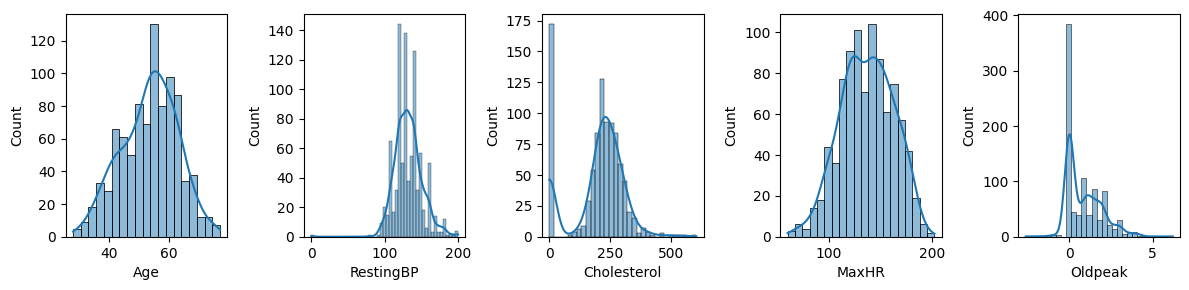

In [ ]:
df = data[['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']]
fig,ax = plt.subplots(1,5,figsize=(12,3))

sns.histplot(df,x='Age',ax=ax[0],kde=True)

sns.histplot(df,x='RestingBP',ax=ax[1],kde=True)

sns.histplot(df,x='Cholesterol',ax=ax[2],kde=True)

sns.histplot(df,x='MaxHR',ax=ax[3],kde=True)

sns.histplot(df,x='Oldpeak',ax=ax[4],kde=True)

plt.tight_layout()


**Count plot**

In [ ]:
cat_data.columns

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

In [ ]:
data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


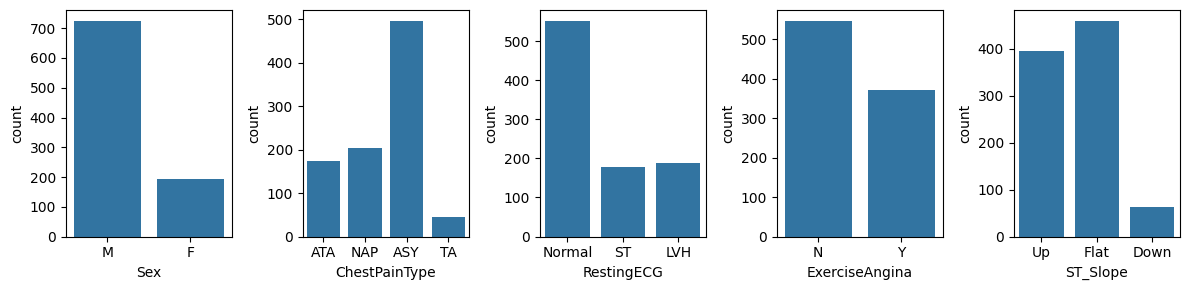

In [ ]:
#cat_data
fig,ax = plt.subplots(1,5,figsize=(12,3))

sns.countplot(data,x='Sex',ax=ax[0])

sns.countplot(data,x='ChestPainType',ax=ax[1])

sns.countplot(data,x='RestingECG',ax=ax[2])

sns.countplot(data,x='ExerciseAngina',ax=ax[3])

sns.countplot(data,x='ST_Slope',ax=ax[4])

plt.tight_layout()

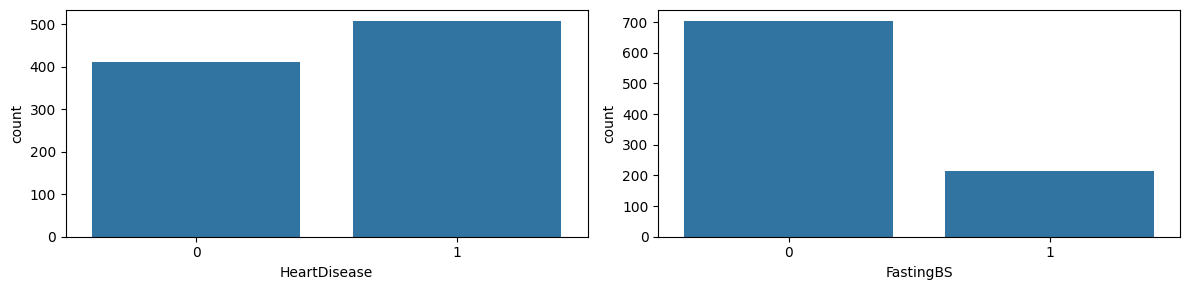

In [ ]:
fig,ax = plt.subplots(1,2,figsize=(12,3))

sns.countplot(data,x='HeartDisease',ax=ax[0])

sns.countplot(data,x='FastingBS',ax=ax[1])


plt.tight_layout()

In [ ]:
data.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

**Box plot**

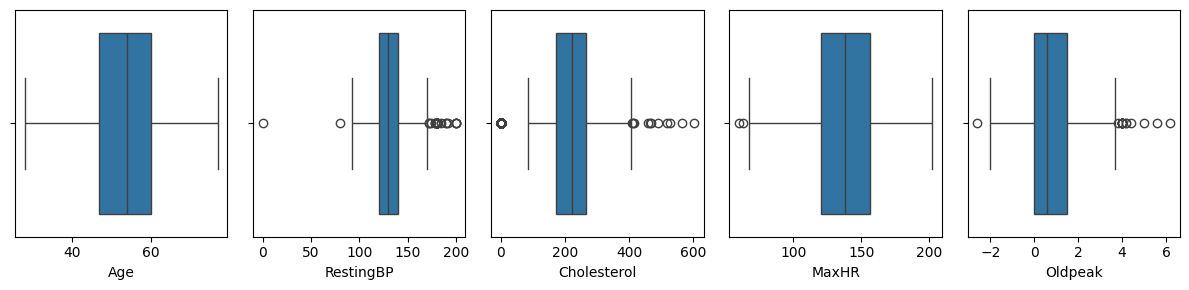

In [ ]:
df = data[['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']]
fig,ax = plt.subplots(1,5,figsize=(12,3))

sns.boxplot(df,x='Age',ax=ax[0])

sns.boxplot(df,x='RestingBP',ax=ax[1])

sns.boxplot(df,x='Cholesterol',ax=ax[2])

sns.boxplot(df,x='MaxHR',ax=ax[3])

sns.boxplot(df,x='Oldpeak',ax=ax[4])

plt.tight_layout()

**scatter plot**

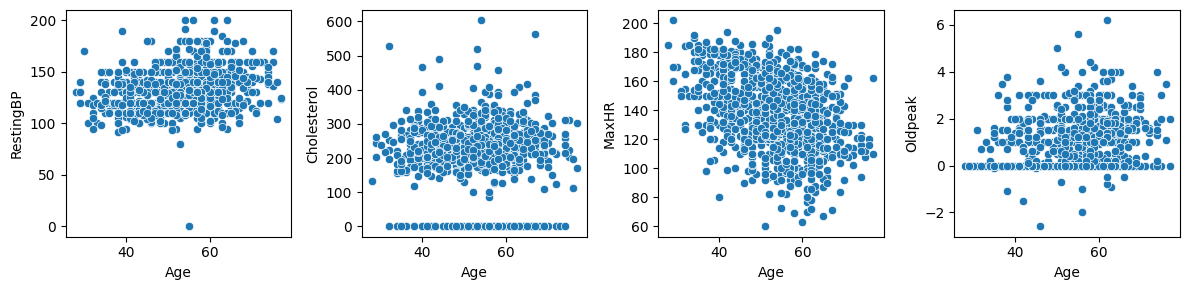

In [ ]:
# age v/s RestingBP	Cholesterol MaxHR Oldpeak
fig,ax = plt.subplots(1,4,figsize=(12,3))
sns.scatterplot(data,x='Age',y='RestingBP',ax=ax[0])
sns.scatterplot(data,x='Age',y='Cholesterol',ax=ax[1])
sns.scatterplot(data,x='Age',y='MaxHR',ax=ax[2])
sns.scatterplot(data,x='Age',y='Oldpeak',ax=ax[3])
plt.tight_layout()

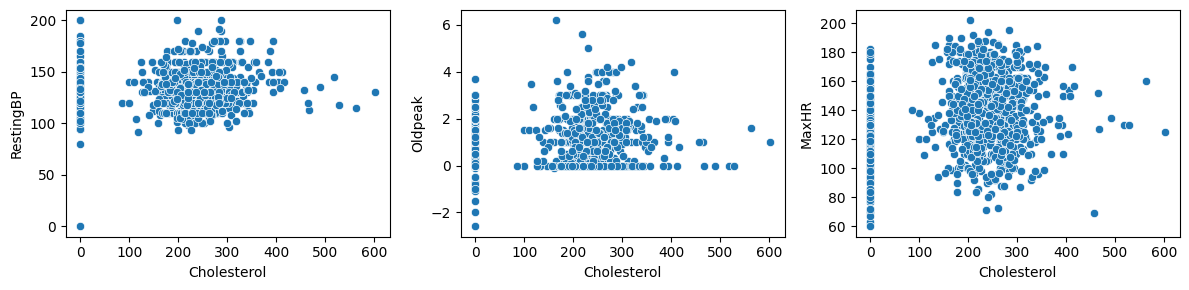

In [ ]:
#Cholesterol v/s RestingBP	Cholesterol MaxHR Oldpeak
fig,ax = plt.subplots(1,3,figsize=(12,3))
sns.scatterplot(data,x='Cholesterol',y='RestingBP',ax=ax[0])
sns.scatterplot(data,x='Cholesterol',y='Oldpeak',ax=ax[1])
sns.scatterplot(data,x='Cholesterol',y='MaxHR',ax=ax[2])

plt.tight_layout()

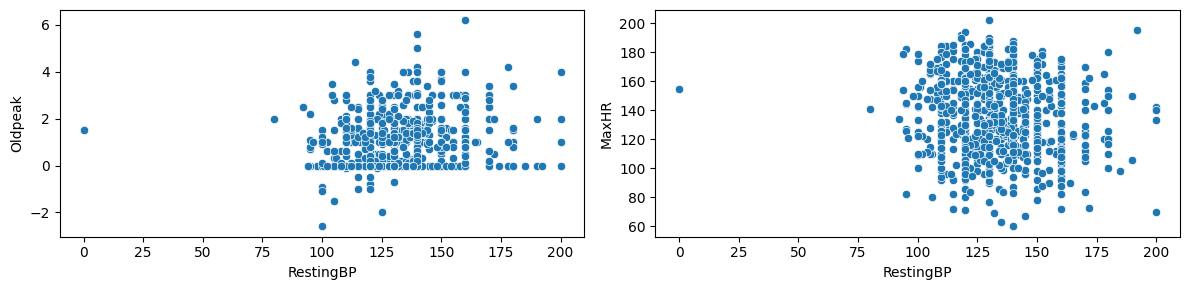

In [ ]:
# RestingBP v/s MaxHR Oldpeak
fig,ax = plt.subplots(1,2,figsize=(12,3))
sns.scatterplot(data,x='RestingBP',y='Oldpeak',ax=ax[0])
sns.scatterplot(data,x='RestingBP',y='MaxHR',ax=ax[1])

plt.tight_layout()


**Bar chart**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('heart.csv')


<Axes: xlabel='Sex', ylabel='Age'>

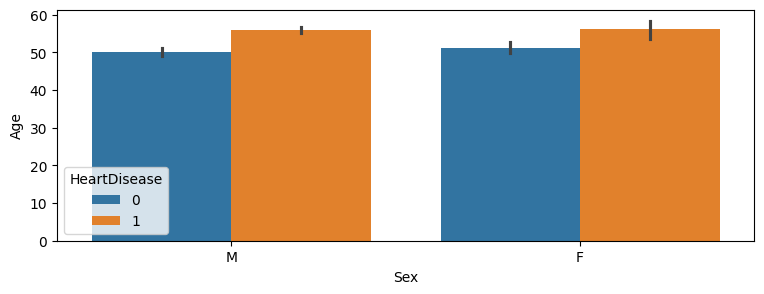

In [ ]:
# gender , Age,heart disease
plt.figure(figsize=(9,3))
sns.barplot(data,x='Sex',y='Age',hue='HeartDisease')

<Axes: xlabel='ChestPainType', ylabel='Cholesterol'>

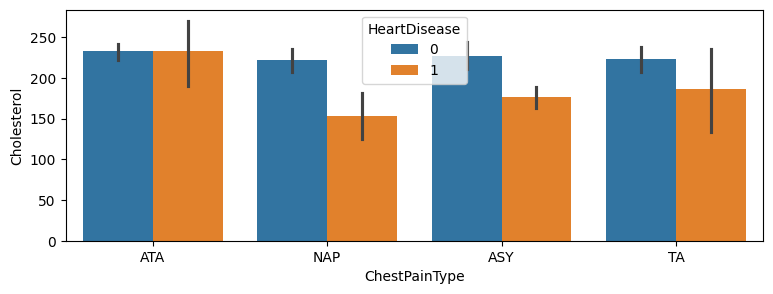

In [ ]:
#ChestPainType , Cholesterol
plt.figure(figsize=(9,3))
sns.barplot(data,x='ChestPainType',y='Cholesterol',hue='HeartDisease')

<Axes: xlabel='RestingECG', ylabel='Cholesterol'>

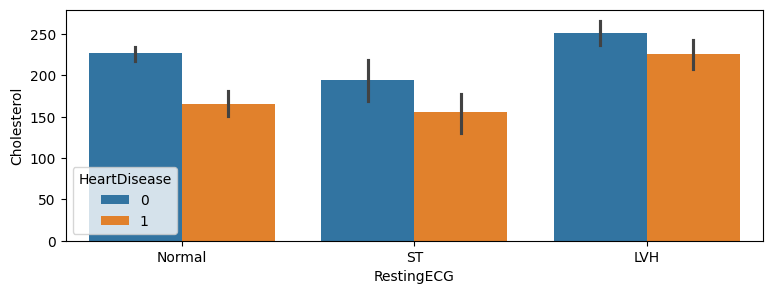

In [ ]:
# RestingECG , Cholesterol
plt.figure(figsize=(9,3))
sns.barplot(data,x='RestingECG',y='Cholesterol',hue='HeartDisease')


In [ ]:
data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


**Pair plot**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("heart.csv")   # replace with your actual file name

In [ ]:
num_data = df.select_dtypes(include=['int64', 'float64'])

# If HeartDisease column is not numeric, add it
num_data['HeartDisease'] = df['HeartDisease']

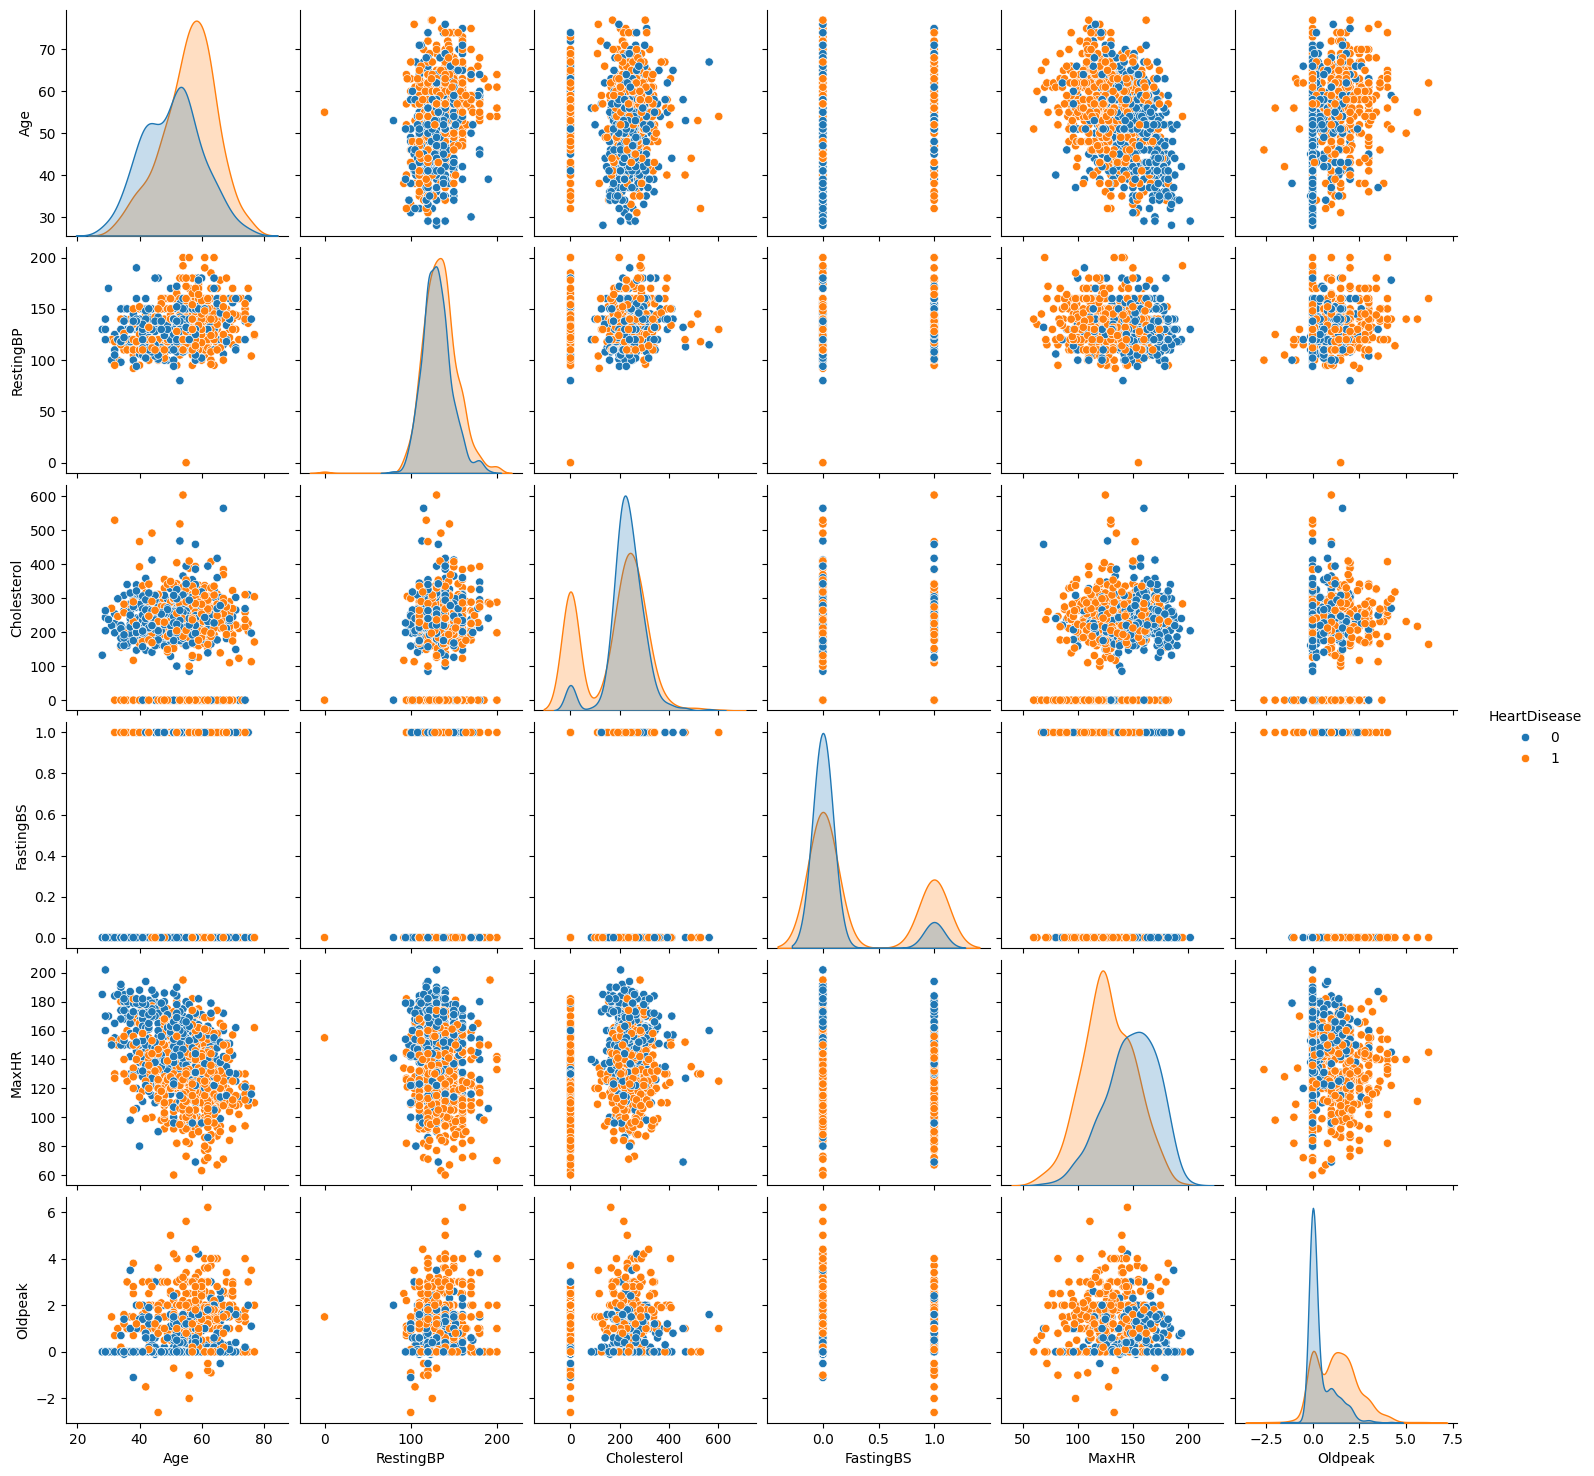

In [ ]:
sns.pairplot(num_data, hue='HeartDisease')
plt.show()

**Heat Map**

In [ ]:
num_data.corr()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000000,0.254399,-0.095282,0.198039,-0.382045,0.258612,0.282039
RestingBP,0.254399,1.000000,0.100893,0.070193,-0.112135,0.164803,0.107589
Cholesterol,-0.095282,0.100893,1.000000,-0.260974,0.235792,0.050148,-0.232741
FastingBS,0.198039,0.070193,-0.260974,1.000000,-0.131438,0.052698,0.267291
MaxHR,-0.382045,-0.112135,0.235792,-0.131438,1.000000,-0.160691,-0.400421
Oldpeak,0.258612,0.164803,0.050148,0.052698,-0.160691,1.000000,0.403951
HeartDisease,0.282039,0.107589,-0.232741,0.267291,-0.400421,0.403951,1.000000


<Axes: >

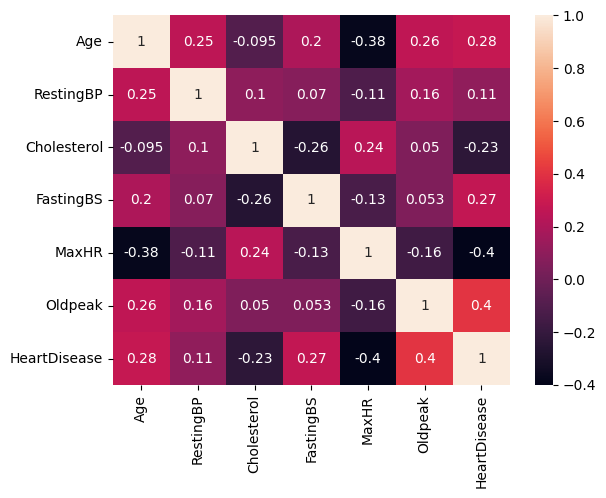

In [ ]:
sns.heatmap(num_data.corr(),annot=True)

## **Handling Outliers**

**Check the outliers directions**

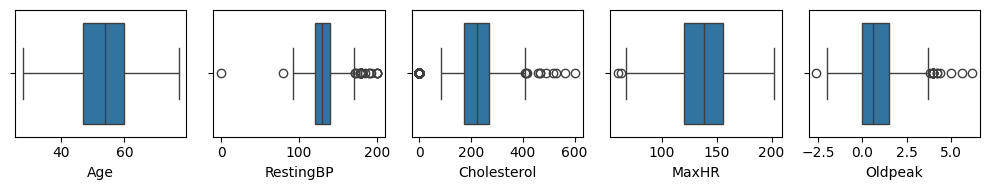

In [ ]:
df = data[['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']]
fig , ax = plt.subplots(1,5,figsize=(10,2))
sns.boxplot(df,x='Age',ax=ax[0])
sns.boxplot(df,x='RestingBP',ax=ax[1])
sns.boxplot(df,x='Cholesterol',ax=ax[2])
sns.boxplot(df,x='MaxHR',ax=ax[3])
sns.boxplot(df,x='Oldpeak',ax=ax[4])
plt.tight_layout()

There are outliers in 'RestingBP','Cholesterol','MaxHR','Oldpeak'

**Check the distribution**

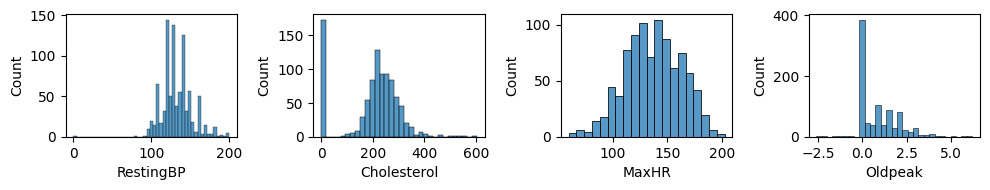

In [ ]:
df = data[['RestingBP','Cholesterol','MaxHR','Oldpeak']]
fig , ax = plt.subplots(1,4,figsize=(10,2))
sns.histplot(df,x='RestingBP',ax=ax[0])
sns.histplot(df,x='Cholesterol',ax=ax[1])
sns.histplot(df,x='MaxHR',ax=ax[2])
sns.histplot(df,x='Oldpeak',ax=ax[3])
plt.tight_layout()

**Skewness**

In [ ]:
df = data[['RestingBP','Cholesterol','MaxHR','Oldpeak']]
for x in df:
  print(x,df[x].skew())

RestingBP 0.1798393100516288
Cholesterol -0.6100864307268192
MaxHR -0.14435941846180994
Oldpeak 1.0228720218107528


**RestingBP distribution is normal**

In [ ]:
# 3 - sigma
mean_val  = data.loc[:,'RestingBP'].mean()
std_val = data.loc[:,'RestingBP'].std()
lower_limit = mean_val- 3 * std_val
upper_limit = mean_val+ 3 * std_val

In [ ]:
# filter values greater than upper limit
data[data.loc[:,'RestingBP']>upper_limit]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
109,39,M,ATA,190,241,0,Normal,106,N,0.0,Up,0
241,54,M,ASY,200,198,0,Normal,142,Y,2.0,Flat,1
365,64,F,ASY,200,0,0,Normal,140,Y,1.0,Flat,1
399,61,M,NAP,200,0,1,ST,70,N,0.0,Flat,1
592,61,M,ASY,190,287,1,LVH,150,Y,2.0,Down,1
732,56,F,ASY,200,288,1,LVH,133,Y,4.0,Down,1
759,54,M,ATA,192,283,0,LVH,195,N,0.0,Up,1


In [ ]:
# filter values less than lower limit
data[data.loc[:,'RestingBP']<lower_limit]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,0,0,0,Normal,155,N,1.5,Flat,1


In [ ]:
len(data[(data.loc[:,'RestingBP']>upper_limit)|(data.loc[:,'RestingBP']<lower_limit)])/len(data)*100

0.8714596949891068

In [ ]:
data.loc[(data.loc[:,'RestingBP']>upper_limit)|(data.loc[:,'RestingBP']<lower_limit),'RestingBP']=data.loc[:,'RestingBP'].mean()

/tmp/ipykernel_845/2742770904.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '132.39651416122004' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[(data.loc[:,'RestingBP']>upper_limit)|(data.loc[:,'RestingBP']<lower_limit),'RestingBP']=data.loc[:,'RestingBP'].mean()


In [ ]:
len(data[(data.loc[:,'RestingBP']>upper_limit)|(data.loc[:,'RestingBP']<lower_limit)])/len(data)*100

0.0

**MaxHR distribution is normal**

In [ ]:
mean_val = data.loc[:,'MaxHR'].mean()
std_val = data.loc[:,'MaxHR'].std()
lower_limit = mean_val - 3 * std_val
upper_limit = mean_val + 3 * std_val

In [ ]:
data[data.loc[:,'MaxHR']>upper_limit]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease


In [ ]:
data[data.loc[:,'MaxHR']<lower_limit]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
390,51,M,ASY,140.0,0,0,Normal,60,N,0.0,Flat,1


In [ ]:
data.loc[data.loc[:,'MaxHR']<lower_limit,'MaxHR']= data.loc[:,'MaxHR'].mean()

/tmp/ipykernel_845/431798854.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '136.80936819172112' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data.loc[:,'MaxHR']<lower_limit,'MaxHR']= data.loc[:,'MaxHR'].mean()


In [ ]:
data[data.loc[:,'MaxHR']<lower_limit]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease


**Cholesterol distribution is skewed**

In [ ]:
#IQR
Q1  = data.loc[:,'Cholesterol'].quantile(0.25)
Q3  = data.loc[:,'Cholesterol'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [ ]:
# filter all values greater than upper limit
data[data.loc[:,'Cholesterol']>upper_limit]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
28,53,F,ATA,113.0,468,0,Normal,127.0,N,0.0,Up,0
30,53,M,NAP,145.0,518,0,Normal,130.0,N,0.0,Flat,1
69,44,M,ASY,150.0,412,0,Normal,170.0,N,0.0,Up,0
76,32,M,ASY,118.0,529,0,Normal,130.0,N,0.0,Flat,1
103,40,M,ASY,120.0,466,1,Normal,152.0,Y,1.0,Flat,1
149,54,M,ASY,130.0,603,1,Normal,125.0,Y,1.0,Flat,1
250,44,M,ASY,135.0,491,0,Normal,135.0,N,0.0,Flat,1
496,58,M,ASY,132.0,458,1,Normal,69.0,N,1.0,Down,0
616,67,F,NAP,115.0,564,0,LVH,160.0,N,1.6,Flat,0
667,65,F,NAP,140.0,417,1,LVH,157.0,N,0.8,Up,0


In [ ]:
# filter all values less than lower_limit
data[data.loc[:,'Cholesterol']<lower_limit]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
293,65,M,ASY,115.0,0,0,Normal,93.0,Y,0.0,Flat,1
294,32,M,TA,95.0,0,1,Normal,127.0,N,0.7,Up,1
295,61,M,ASY,105.0,0,1,Normal,110.0,Y,1.5,Up,1
296,50,M,ASY,145.0,0,1,Normal,139.0,Y,0.7,Flat,1
297,57,M,ASY,110.0,0,1,ST,131.0,Y,1.4,Up,1
...,...,...,...,...,...,...,...,...,...,...,...,...
514,43,M,ASY,122.0,0,0,Normal,120.0,N,0.5,Up,1
515,63,M,NAP,130.0,0,1,ST,160.0,N,3.0,Flat,0
518,48,M,NAP,102.0,0,1,ST,110.0,Y,1.0,Down,1
535,56,M,ASY,130.0,0,0,LVH,122.0,Y,1.0,Flat,1


In [ ]:
# find %
len(data[(data.loc[:,'Cholesterol']>upper_limit)|(data.loc[:,'Cholesterol']<lower_limit)])/len(data)*100

19.934640522875817

**Oldpeak distribution is normal**

In [ ]:
Q1 = data.loc[:,'Oldpeak'].quantile(0.25)
Q3 = data.loc[:,'Oldpeak'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [ ]:
data[data.loc[:,'Oldpeak']>upper_limit]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
68,52,M,ASY,160.000000,246,0,ST,82.0,Y,4.0,Flat,1
166,50,M,ASY,140.000000,231,0,ST,140.0,Y,5.0,Flat,1
500,65,M,ASY,136.000000,248,0,Normal,140.0,Y,4.0,Down,1
521,61,M,ASY,120.000000,282,0,ST,135.0,Y,4.0,Down,1
537,74,M,ASY,150.000000,258,1,ST,130.0,Y,4.0,Down,1
559,64,M,ASY,134.000000,273,0,Normal,102.0,Y,4.0,Down,1
624,63,F,ASY,150.000000,407,0,LVH,154.0,N,4.0,Flat,1
702,59,M,TA,178.000000,270,0,LVH,145.0,N,4.2,Down,0
732,56,F,ASY,132.396514,288,1,LVH,133.0,Y,4.0,Down,1
771,55,M,ASY,140.000000,217,0,Normal,111.0,Y,5.6,Down,1


In [ ]:
data[data.loc[:,'Oldpeak']<lower_limit]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
324,46,M,ASY,100.0,0,1,ST,133.0,N,-2.6,Flat,1


In [ ]:
len(data[(data.loc[:,'Oldpeak']>upper_limit)|(data.loc[:,'Oldpeak']<lower_limit)])/len(data)*100

1.7429193899782136

In [ ]:
data.loc[(data.loc[:,'Oldpeak']>upper_limit)|(data.loc[:,'Oldpeak']<lower_limit) , 'Oldpeak']= data.loc[:,'Oldpeak'].median()

In [ ]:
len(data[(data.loc[:,'Oldpeak']>upper_limit)|(data.loc[:,'Oldpeak']<lower_limit)])/len(data)*100

0.0

## **Encoding Technique**
- Label Encoder
- one hot encoder
- manual encoder

In [ ]:
# Sex,ExerciseAngina
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data.loc[:,'Sex']= le.fit_transform(data.loc[:,'Sex'])
data.loc[:,'ExerciseAngina']= le.fit_transform(data.loc[:,'ExerciseAngina'])

In [ ]:
# Sex  - Label encoder
# ChestPainType - one hot
# RestingECG - one hot
# ExerciseAngina label encoder
# ST_Slope - taget encoder/manual encoder
data =pd.get_dummies(data,columns=['RestingECG','ChestPainType'],dtype='int')
data

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA
0,40,1,140.0,289,0,172.0,0,0.0,Up,0,0,1,0,0,1,0,0
1,49,0,160.0,180,0,156.0,0,1.0,Flat,1,0,1,0,0,0,1,0
2,37,1,130.0,283,0,98.0,0,0.0,Up,0,0,0,1,0,1,0,0
3,48,0,138.0,214,0,108.0,1,1.5,Flat,1,0,1,0,1,0,0,0
4,54,1,150.0,195,0,122.0,0,0.0,Up,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,110.0,264,0,132.0,0,1.2,Flat,1,0,1,0,0,0,0,1
914,68,1,144.0,193,1,141.0,0,3.4,Flat,1,0,1,0,1,0,0,0
915,57,1,130.0,131,0,115.0,1,1.2,Flat,1,0,1,0,1,0,0,0
916,57,0,130.0,236,0,174.0,0,0.0,Flat,1,1,0,0,0,1,0,0


<Axes: xlabel='ST_Slope', ylabel='HeartDisease'>

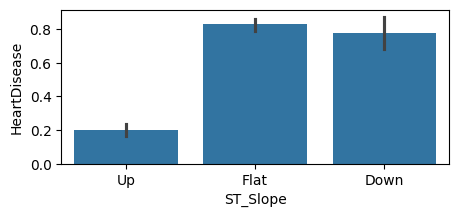

In [ ]:
plt.figure(figsize=(5,2))
sns.barplot(data,x='ST_Slope',y='HeartDisease')

In [ ]:
data.loc[:,'ST_Slope']= data.loc[:,'ST_Slope'].map({'Up':0,'Down':1,'Flat':2})


In [ ]:
# Age , RestingBP,Cholesterol,MaxHR,Oldpeak

## **Scaling**
- standard scaler
- min max scaler

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
columns = ['Age' , 'RestingBP','Cholesterol','MaxHR','Oldpeak']
data[columns] = scaler.fit_transform(data[columns])


## **Feature Engineering**

In [ ]:
data

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA
0,-1.433140,1,0.464762,0.825070,0,1.386546,0,-0.866238,0,0,0,1,0,0,1,0,0
1,-0.478484,0,1.634819,-0.171961,0,0.754627,0,0.178162,2,1,0,1,0,0,0,1,0
2,-1.751359,1,-0.120267,0.770188,0,-1.536076,0,-0.866238,0,0,0,0,1,0,1,0,0
3,-0.584556,0,0.347756,0.139040,0,-1.141127,1,0.700363,2,1,0,1,0,1,0,0,0
4,0.051881,1,1.049790,-0.034755,0,-0.588199,0,-0.866238,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,1,-1.290324,0.596393,0,-0.193250,0,0.387042,2,1,0,1,0,0,0,0,1
914,1.536902,1,0.698773,-0.053049,1,0.162204,0,2.684723,2,1,0,1,0,1,0,0,0
915,0.370100,1,-0.120267,-0.620168,0,-0.864663,1,0.387042,2,1,0,1,0,1,0,0,0
916,0.370100,0,-0.120267,0.340275,0,1.465535,0,-0.866238,2,1,1,0,0,0,1,0,0


## **Split data for x and y**

In [ ]:
x = data.drop(columns ='HeartDisease')
y = data.loc[:,'HeartDisease']

## **Split for training and testing**

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


## **Balancing data**
- Over sampling
- under sampling
- Smote

<Axes: xlabel='HeartDisease', ylabel='count'>

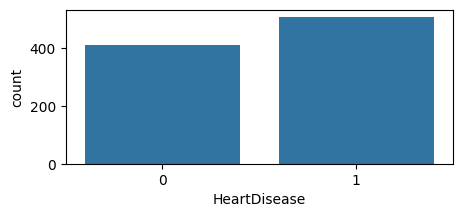

In [ ]:
# plot count plot for target
plt.figure(figsize=(5,2))
sns.countplot(data,x='HeartDisease')

Data is Imbalanced. The observations related to positive class are high compared to negative class.

In [ ]:
#Smote
from imblearn.over_sampling import SMOTE
from collections import Counter
smote=SMOTE(random_state=42)
x_sampled,y_sampled=smote.fit_resample(x_train,y_train)
#balancing should be done on train data

In [ ]:
#before balancing
Counter(y_train)

Counter({0: 333, 1: 401})

In [ ]:
#after balancing
Counter(y_sampled)

Counter({0: 401, 1: 401})

## **Model Building**

In [ ]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_sampled,y_sampled)



LogisticRegression()

In [ ]:
# Model predictions
y_pred =model.predict(x_test)

## **Evaluating the model**
- Confusion matrix
- accuracy
- recall
- precision
- f1 score
- auc-roc curve
- log loss

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,f1_score

In [ ]:
confusion_matrix(y_test,y_pred)

array([[68,  9],
       [17, 90]])

In [ ]:
accuracy_score(y_test,y_pred)

0.8586956521739131

In [ ]:
precision_score(y_test,y_pred)

0.9090909090909091

In [ ]:
recall_score(y_test,y_pred)

0.8411214953271028

In [ ]:
f1_score(y_test,y_pred)

0.8737864077669902

In [ ]:
#auc - roc
from sklearn.metrics import roc_auc_score,roc_curve

In [ ]:
y_prob=model.predict_proba(x_test)[:,1]
#convert 2D array into 1D array
y_prob


array([0.01984599, 0.14277777, 0.96918056, 0.97666246, 0.03468568,
       0.88280882, 0.82559034, 0.08096029, 0.7933372 , 0.94664104,
       0.72083444, 0.08961197, 0.61584282, 0.06299051, 0.92412597,
       0.73122933, 0.01569155, 0.87147767, 0.76982603, 0.09423187,
       0.79339696, 0.77767324, 0.03164117, 0.70718452, 0.83200895,
       0.89475182, 0.04285238, 0.80471137, 0.04895064, 0.03250277,
       0.73320739, 0.15410546, 0.74270531, 0.93676887, 0.73020029,
       0.31746127, 0.937545  , 0.03754299, 0.9087726 , 0.62844368,
       0.85103614, 0.80381316, 0.69683484, 0.13690916, 0.07441667,
       0.81369159, 0.40839303, 0.97558141, 0.95285849, 0.38794847,
       0.04215192, 0.02956451, 0.72765082, 0.90718313, 0.67176193,
       0.12177565, 0.26877815, 0.90166684, 0.406315  , 0.89379979,
       0.20931909, 0.06523246, 0.00967503, 0.95491407, 0.05681608,
       0.98619361, 0.98408327, 0.9284816 , 0.96914481, 0.519607  ,
       0.28035455, 0.05128663, 0.86258874, 0.64151825, 0.22439

In [ ]:
#roc_auc_curve
roc_auc_score(y_test,y_prob)

np.float64(0.9253550188129627)

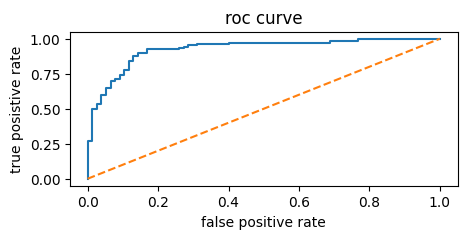

In [ ]:
#roc curve
fpr,tpr,threshold=roc_curve(y_test,y_prob)
plt.figure(figsize=(5,2))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel('false positive rate')
plt.ylabel('true posistive rate')
plt.title('roc curve')
plt.show()

#**KNN Classifier**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=3)
model.fit(x_sampled,y_sampled) #training
y_pred = model.predict(x_test) #testing

# Evaluate the model

In [ ]:
#confusion matrix
confusion_matrix(y_test,y_pred)

array([[68,  9],
       [19, 88]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.8478260869565217

In [ ]:
# recall
recall_score(y_test,y_pred)

0.822429906542056

In [ ]:
# precision
precision_score(y_test,y_pred)

0.9072164948453608

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.8627450980392157

In [ ]:
# auc-roc-score
y_prob = model.predict_proba(x_test)[:,1]
# convert 2d array to 1 d array


In [ ]:
# roc curve
roc_auc_score(y_test,y_prob)

np.float64(0.8953756523849983)

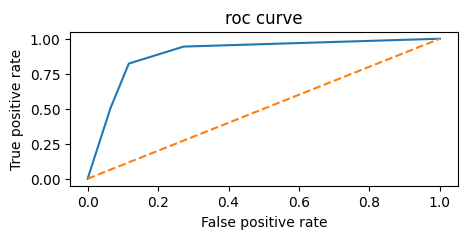

In [ ]:
fpr,tpr,threshold=roc_curve(y_test,y_prob)
plt.figure(figsize=(5,2))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('roc curve')
plt.show()

In [ ]:
error_rate=[]

for k in range(2,11):
  model = KNeighborsClassifier(n_neighbors=k)
  model.fit(x_sampled,y_sampled)
  y_pred=model.predict(x_test)
  error_rate.append(np.mean(y_test!=y_pred))
error_rate


[np.float64(0.22282608695652173),
 np.float64(0.15217391304347827),
 np.float64(0.1956521739130435),
 np.float64(0.16847826086956522),
 np.float64(0.1956521739130435),
 np.float64(0.15760869565217392),
 np.float64(0.16847826086956522),
 np.float64(0.16847826086956522),
 np.float64(0.16847826086956522)]

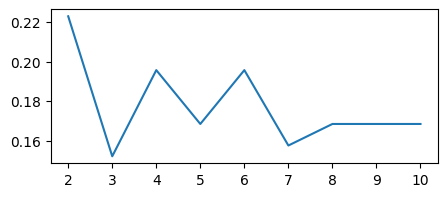

In [ ]:
plt.figure(figsize=(5,2))
plt.plot(range(2,11),error_rate)

# Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion='gini',splitter='best',max_features='sqrt',min_samples_split=5,min_samples_leaf=3)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[62, 15],
       [28, 79]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.7663043478260869

In [ ]:
# recall
recall_score(y_test,y_pred)

0.7383177570093458

In [ ]:
# precision
precision_score(y_test,y_pred)

0.8404255319148937

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.7860696517412935

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.7717562811020755)

# Cross validation

## K Fold

In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
model = DecisionTreeClassifier(criterion='gini',splitter='best',max_features='sqrt',min_samples_split=5,min_samples_leaf=3)
kfold = KFold(n_splits=5, shuffle=True,random_state=42)
scores=cross_val_score(model,x_sampled,y_sampled,cv=kfold)

In [ ]:
scores

array([0.77018634, 0.8136646 , 0.76875   , 0.79375   , 0.76875   ])

In [ ]:
print(np.mean(scores))

0.7830201863354038


# Startified K Fold

In [ ]:
from sklearn.model_selection import StratifiedKFold
model = DecisionTreeClassifier(criterion='gini',splitter='best',max_features='sqrt',min_samples_split=5,min_samples_leaf=3)
sfold = StratifiedKFold(n_splits=5, shuffle=True,random_state=42)
scores= cross_val_score(model,x_sampled,y_sampled,cv=sfold)

In [ ]:
scores

array([0.86335404, 0.75776398, 0.78125   , 0.81875   , 0.825     ])

In [ ]:
print(np.mean(scores))

0.809223602484472
